<h1><center>Data science for Geographers</center></h1>

<h2><center>Practical 2 - Plotting, visualisation and multiple regression in Python</center></h2>

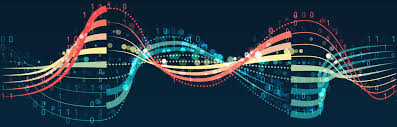

## Contents<a class="anchor" id="contents"></a>

- 1. [Introduction](#section1)
    - [Reminder: What are we trying to do?](#section1.1)
    - [Exercise](#exercise1)
- 2. [Summarising and visualising](#section2)
    - [Summary statistics and tables](#section2.1)
    - [Plots (boxplots and histograms)](#section2.2)
    - [An aside about plotting](#section2.3)
    - [Saving plots for presentations or publication](#section2.4)
    - [Creating 'Table 1'](#section2.5)
    - [Exercise](#exercise2)
- 3. [Linear Regression in Python](#section3)
    - [Simple Linear Regression](#section3.1)
    - [Multiple Linear Regression](#section3.2)
- 4. [Independent analysis exercises](#section4)
- 5. [Some tips on good Coding Practice](#section5)

## 1. Introduction<a class="anchor" id="section1"></a>

### Reminder: What are we trying to do?<a class="anchor" id="section1.1"></a>

If you remember from the previous practical, we are going through all of the steps for a research project using secondary quantitative data. In our particular example, we are undertaking a research project where we are interested in the geography of the availability of tobacco products (i.e. similar to the paper below):

https://tobaccocontrol.bmj.com/content/tobaccocontrol/25/1/75.full.pdf

Last week, we went through the process of cleaning, recoding and merging the datasets together so that by the end we had a dataset ready to answer our research questions. This final dataset consists of an area-level dataset (as opposed to individual level data for example). Our unit of analysis is datazones and for each datazone we have information on the level of deprivation (in terms of employment levels, health, education and income), the numbers of tobacco retailers per unit of population, smoking rates among pregnant women and whether the area is urban or rural. Our simulated version of Scotland has 1,600 datazones and, after removing the datazones with no smoking data last week, we now have a dataset with 1,583 rows of data which looks like this:

| datazone | retailer_count | total_population | simd_decile | simd_rank | simd_quintile | income_rank | health_rank | smoking_rate | ... |
|---|---|---|---|---|---|---|---|---|---|
| DZ00005 | 1 | 865 | 8 | 1143 | 4 | 1391 | 1276 | 8.7 | ... |
| DZ00006 | 1 | 614 | 2 | 204 | 1 | 261 | 334 | 14.81 | ... |
| DZ00007 | 2 | 784 | 2 | 233 | 1 | 198 | 240 | 27.78 | ... |
| DZ00008 | 1 | 858 | 5 | 779 | 3 | 973 | 613 | 24 | ... |
| DZ00014 | 3 | 913 | 2 | 314 | 1 | 376 | 329 | 19.51 | ... |
| DZ00018 | 2 | 718 | 1 | 37 | 1 | 40 | 59 | 21.74 | ... |

(Remember that all of this data is simulated, so our results won't tell us anything about real tobacco retailing in Scotland!)

Before we move on, here is a reminder of what all of this is for. The map below shows the smoking rate in each of our datazones (the darker the colour, the higher the smoking rate). As you can see, smoking rates vary a lot from one datazone to the next. Some datazones have hardly any smoking at all while in others more than a third of pregnant women smoke. Ultimately, it is this <b>variation</b> that we are trying to explain! (The handful of grey datazones are the ones with no smoking data that we removed last week.)

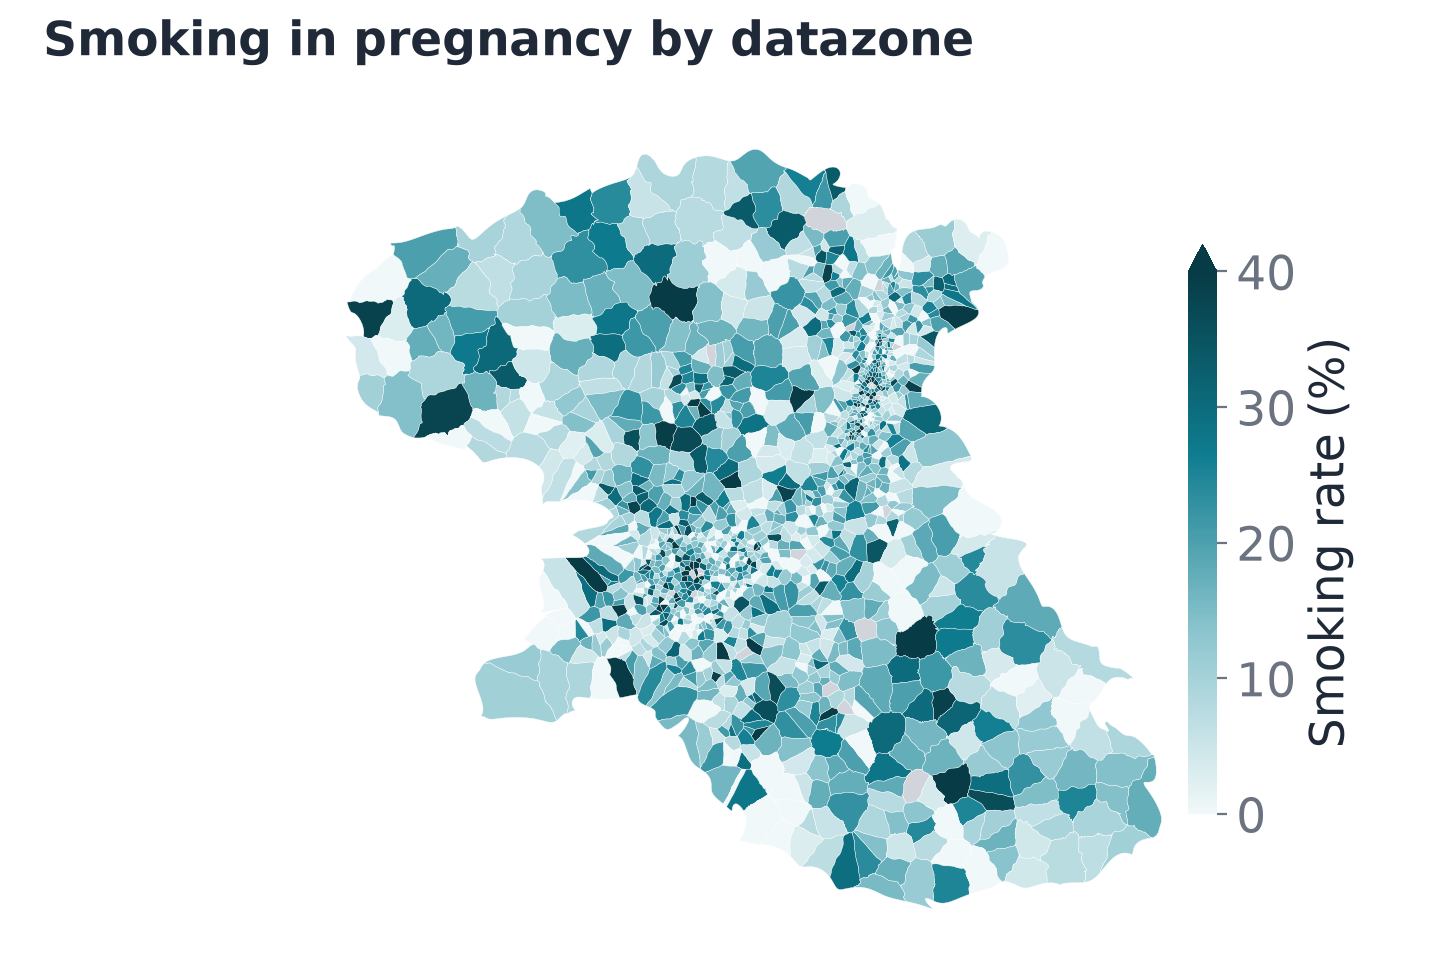

So, we have got the boring part out of the way! Now it's on to the interesting part, the actual analysis of this data! Let's first establish the three research questions we are going to try and answer today. What we are going to do today is showcase how we might approach answering questions like these:

1. Is the number of tobacco retailers in urban areas associated with smoking rates in datazones in Scotland?
2. Is this association independent of the level of deprivation in these datazones?
3. Is the level of deprivation in urban datazones associated with the number of tobacco retailers?

First thing we have to do, as always, is load in the packages we need. As last week we are going to be using pandas for all of our data wrangling. So, let's import that now...

In [ ]:
#First let's load in the packages we need - we will import some more below
import pandas as pd

This week we are also going to be using some additional packages, beyond pandas. Let's start with the plotting. The most widely used package for plots in Python is `matplotlib` and we are going to use it alongside `seaborn`, which is built on top of matplotlib and makes it much easier to produce the kinds of statistical plots we need (if you have used `ggplot` in R, seaborn is the closest thing to it). We are also going to need `statsmodels` for our regression models.

Some of these may not have been installed by default. We can install packages using the `%pip install` command. Note this command will take some time to complete so be patient!

In [ ]:
%pip install seaborn statsmodels

Now we can import them. As with pandas, each of these has a nickname that everybody uses...

In [ ]:
import matplotlib.pyplot as plt #for plots
import seaborn as sns #for nicer plots with less code
import statsmodels.formula.api as smf #for regression models

It's also now becoming more commonplace to produce plots and graphs in colours that are colourblind-friendly. Python makes this easy for us as the `viridis` palette comes built in to both matplotlib and seaborn, so there is nothing extra to install. We will use it later in the practical.

Lastly, we are going to produce some tables of descriptive statistics, including one of the most common tables that you will need ('Table 1'). We don't need anything new for these as pandas can do all of it for us.

With all of our packages installed, now let's read the data we created in last weeks practical...

In [ ]:
analysis_data = pd.read_csv("merged_data.csv")

And take a look at the data to remind ourselves what is there...

In [ ]:
analysis_data.head()

### Exercise <a class="anchor" id="exercise1"></a>

To refresh our memories from last week, lets do one more variable recode to see what you can remember:

1. Create new variables called `health_quintile` and `retailers_adj_quintile`. These should be based on the existing `health_rank` and `retailers_adj` variables but dividing them into five equal groups.

2. Change these two new variables so that they are categorical variables. Label the `health_quintile` the same as the other "quintile" variables i.e. "Most deprived", "Second, "Third", "Fourth" and "Least deprived". Label the `retailer_adj` as you see fit.

3. Change the variables `simd_quintile` and `simd_decile` into categorical variables and relabel appropriately (you'll need to think of labels for the `simd_decile` variable.

Bonus points if you can figure out how to do tasks 1 and 2 in one command using method chaining!

<b>Hint: you can use `pd.qcut()` here as well as `astype('category')` and `.cat.rename_categories()`. Refer back to last weeks notebook if you get stuck!</b>

<b>One more hint: you will find that `pd.qcut()` gives you an error when you try it on `retailers_adj` (have a read of the error message and see if you can work out why!). To get around this, rank the datazones first by putting `analysis_data['retailers_adj'].rank(method="first")` inside `pd.qcut()` instead of the variable itself. I explain what is going on just below the exercise.</b>

Enter your answers into the empty code cell below. Once you have had a go, the solutions are in the hidden cell underneath it: click on the three dots (`...`) to reveal the code. Make sure you run the solutions cell before moving on as some of the code later in the practical may rely on it!

In [ ]:
#1
analysis_data['health_quintile'] = pd.qcut(analysis_data['health_rank'], 5, labels=False) + 1

#retailers_adj has lots of tied values so we rank the datazones first (see the note below)
analysis_data['retailers_adj_quintile'] = pd.qcut(analysis_data['retailers_adj'].rank(method="first"), 5, labels=False) + 1

#2
analysis_data['retailers_adj_quintile'] = (
    analysis_data['retailers_adj_quintile']
    .astype('category')
    .cat.rename_categories({1: "Lowest availability",
                            2: "Second",
                            3: "Third",
                            4: "Fourth",
                            5: "Highest availability"})
)

analysis_data['health_quintile'] = (
    analysis_data['health_quintile']
    .astype('category')
    .cat.rename_categories({1: "Most deprived", 2: "Second", 3: "Third", 4: "Fourth", 5: "Least deprived"})
)

# #bonus solution!
# analysis_data['health_quintile'] = (
#     (pd.qcut(analysis_data['health_rank'], 5, labels=False) + 1)
#     .astype('category')
#     .cat.rename_categories({1: "Most deprived", 2: "Second", 3: "Third", 4: "Fourth", 5: "Least deprived"})
# )
# analysis_data['retailers_adj_quintile'] = (
#     (pd.qcut(analysis_data['retailers_adj'].rank(method="first"), 5, labels=False) + 1)
#     .astype('category')
#     .cat.rename_categories({1: "Lowest availability", 2: "Second", 3: "Third", 4: "Fourth", 5: "Highest availability"})
# )

#3
analysis_data['simd_quintile'] = (
    analysis_data['simd_quintile']
    .astype('category')
    .cat.rename_categories({1: "Most deprived", 2: "Second", 3: "Third", 4: "Fourth", 5: "Least deprived"})
)

analysis_data['simd_decile'] = (
    analysis_data['simd_decile']
    .astype('category')
    .cat.rename_categories({1: "Most deprived",
                            2: "Second",
                            3: "Third",
                            4: "Fourth",
                            5: "Fifth",
                            6: "Sixth",
                            7: "Seventh",
                            8: "Eighth",
                            9: "Ninth",
                            10: "Least deprived"})
)

A quick note on the `retailers_adj_quintile` variable we just created. Let's look at the range of values in each of the five groups...

In [ ]:
(
    analysis_data
    .groupby('retailers_adj_quintile', observed=True)['retailers_adj']
    .agg(['count', 'min', 'max'])
)

Notice anything odd? The first group contains only datazones with zero retailers, and so does most of the second group! This is because about 4 in 10 of our datazones don't have any tobacco retailers at all, so there are far more zeros than will fit into one fifth of the data. This is also why `pd.qcut()` gave us an error when we tried it on `retailers_adj` directly. The cut-offs for the first <b>and</b> second groups are both zero and `qcut()` refuses to make two groups with the same cut-off. Ranking the datazones first with `rank(method="first")` gets around this by numbering the datazones from lowest to highest, with tied datazones simply numbered in the order they appear in the data. So all of these tied values get split between the first two groups, and this is done arbitrarily. So two datazones with exactly the same number of retailers (zero) can end up in different groups. This is something to watch out for whenever you divide a variable with lots of identical values into equal groups. In a real project we would probably want to create a separate "no retailers" group instead. The picture below shows what is going on:

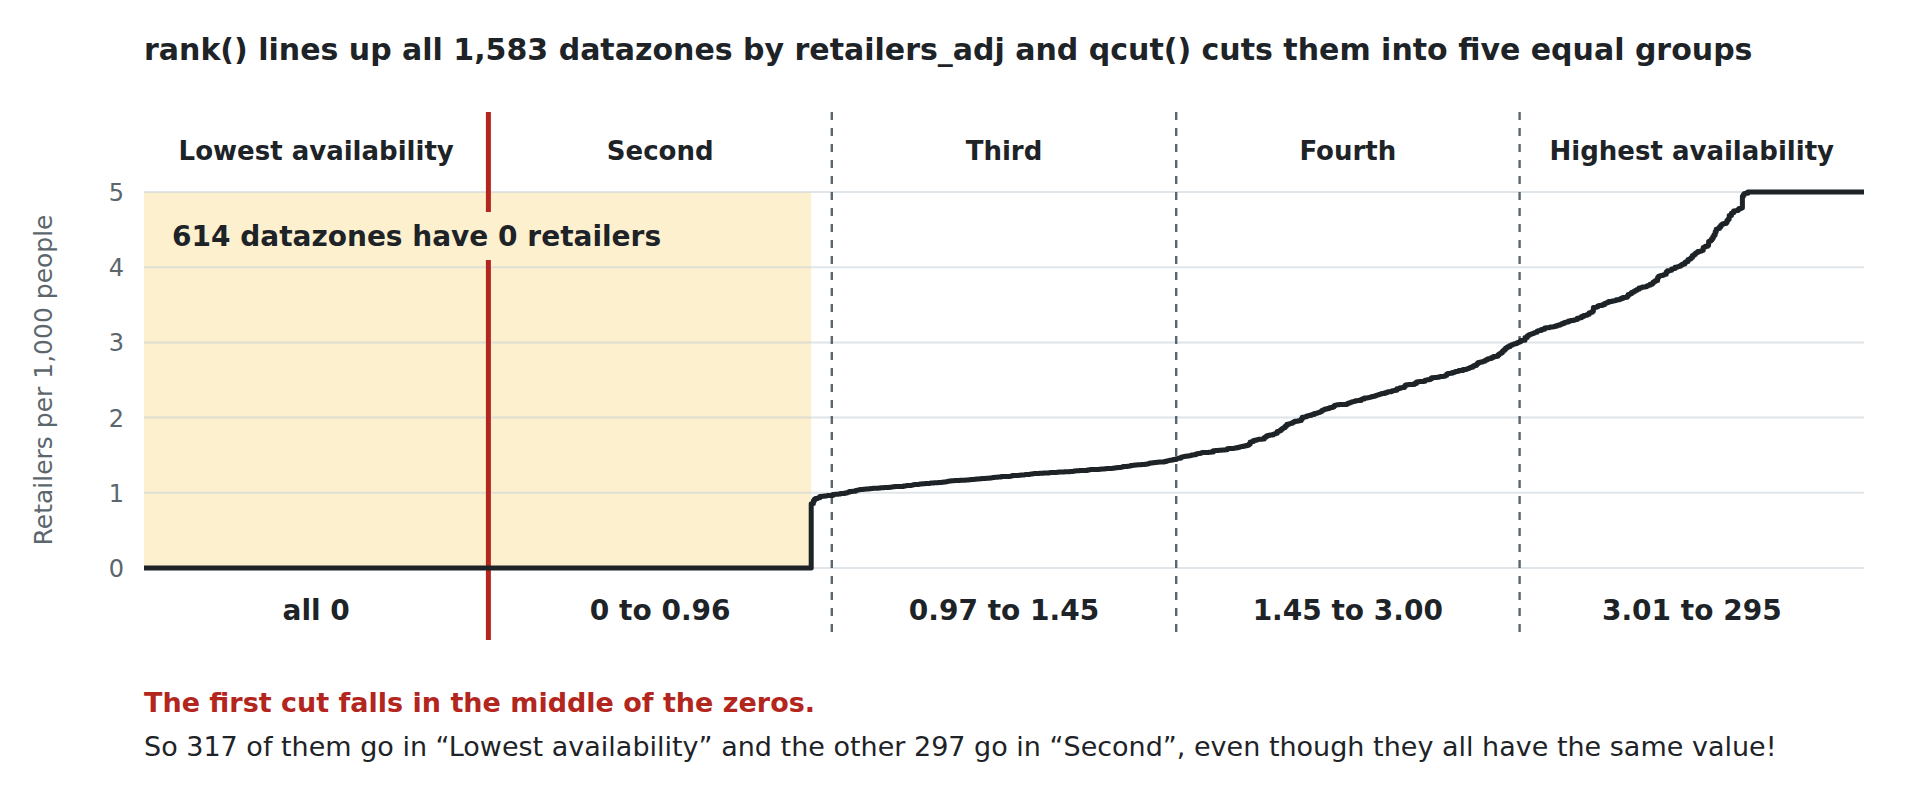

[Back to contents](#contents)

## 2. Summarising and visualising<a class="anchor" id="section2"></a>

### Summary statistics and tables<a class="anchor" id="section2.1"></a>

Before we get stuck into the modelling for our research questions, let's draw up some plots and descriptives of our data. You should have some familiarity with these commands from "Key Methods".


First let's look at some of our categorical variables using `value_counts()`.

In [ ]:
#Tables for the categorical variables
#(sort=False keeps the categories in their proper order rather than sorting by the counts)
print(analysis_data['urban_rural'].value_counts())

print(analysis_data['simd_quintile'].value_counts(sort=False))

print(analysis_data['simd_decile'].value_counts(sort=False))

print(analysis_data['health_quintile'].value_counts(sort=False))

Now let's look at some of the continuous variables using `describe()`...

Remember when looking at the below code that the square brackets are how we select a particular variable from a dataset...

In [ ]:
#Summaries for continuous variables
print(analysis_data['simd_rank'].describe())
print(analysis_data['total_population'].describe())

Note that you can also look at all variables together by just using `describe()` with just the DataFrame. Like...

In [ ]:
analysis_data.describe()

You might be wondering why pandas doesnt try and do summaries for all of the variables? Well, because we have told pandas which of our variables are categorical and which are numerical (continuous) it knows which variables to include in the summary i.e. only the numerical ones.

If you would like a summary of all of the variables in the dataset you can add `include='all'`. We also add `.T` on the end, which "transposes" the table (i.e. swaps the rows and columns) so that each variable gets its own row.

In [ ]:
analysis_data.describe(include='all').T

It is worth taking some time looking at this output as it contains some useful information. Note that each row is a variable and the columns contain some summary information about the variables. For the categorical variables `unique` is the number of categories, `top` is the most common category and `freq` is the number of datazones in it. A `NaN` here just means that the summary doesn't apply to that kind of variable (e.g. you can't take the mean of a category!).

### Plots (boxplots and histograms)<a class="anchor" id="section2.2"></a>

It is also good practice to look at our data using graphs and plots, particularly boxplots and histograms.

Let's look at the `retailers_adj` variable.

The various lines of code below offer lots of options for creating different histograms and boxplots. Most of it should be familiar to you!

In [ ]:
#Histogram and boxplot for the tobacco retailers
sns.set_style("whitegrid") #a cleaner look for all of our plots

sns.histplot(data=analysis_data, x='retailers_adj', binwidth=0.5)
plt.show()

In [ ]:
#We can also add in a second variable to see the distribution of retailers over that variable, e.g.
sns.histplot(data=analysis_data, x='retailers_adj', hue='simd_quintile', multiple='stack',
             binwidth=0.5, palette='viridis')
plt.show()

In [ ]:
#Or we can divide this into separate plots using displot and the col option
sns.displot(data=analysis_data, x='retailers_adj', hue='simd_quintile', col='simd_quintile', col_wrap=3,
            binwidth=0.5, palette='viridis', height=3)
plt.show()

In [ ]:
sns.boxplot(data=analysis_data, x='retailers_adj')
plt.show()

#Some other plots we might want to look at:

#sns.histplot(data=analysis_data, x='smoking_rate', binwidth=0.1)
#plt.show()

Looking at these graphs, you can see there are a handful of datazones with extremely high numbers of retailers per 1000 people (look at the far right of the histograms and the dots on the far right of the boxplot). Let's have a look at them...

In [ ]:
analysis_data[analysis_data['retailers_adj'] > 100][['datazone', 'retailer_count', 'total_population', 'retailers_adj', 'urban_rural']]

There are six of them and they are all tiny city-centre datazones with fewer than 100 residents but lots of shops, which is why their rates are so extreme. Rates based on such small populations are very unstable and, as we will see in a later practical, just a few extreme observations like these can have a big influence on our results. So it seems we need to trim these outlying observations (removing observations with retailers greater than 100 per 1000 population). Note that decisions like this are always a judgement call and are something you should always report in your write-up!

If you want to see just how much difference these six datazones make, have a go with the <b>outlier explorer</b> (there's a link to it below) once you have finished the regression section of this practical. It lets you move the cut-off up and down and watch what happens to the regression line.

https://tc245.github.io/data-science-apps/outliers/

In [ ]:
analysis_data = analysis_data[analysis_data['retailers_adj'] <= 100].copy()

# this code retains only those datazones with 100 or fewer retailers per 1000 population
# '<=' means 'less than or equal to'
# .copy() makes sure we get a completely new DataFrame (otherwise pandas can complain when we add variables to it later)

In many cases, boxplots are more useful when combined with categorical variables...

In [ ]:
#boxplot smoking rate by simd quintiles
sns.boxplot(data=analysis_data, x='simd_quintile', y='smoking_rate')
plt.show()

#boxplot retailers by simd quintiles
sns.boxplot(data=analysis_data, x='simd_quintile', y='retailers_adj')
plt.show()

### An aside about plotting<a class="anchor" id="section2.3"></a>

There are many options for customising your plots using `seaborn` and `matplotlib`. Above we have changed the look of our plots using `sns.set_style` and created multiple plots using `sns.displot`. For more options check out https://seaborn.pydata.org/examples/index.html and https://matplotlib.org/cheatsheets/

We have also used the `viridis` palette to set the colours used in our plots. Viridis is colourblind-friendly and retains clarity when printed in greyscale - it also looks nice! There are a lot of places online where you can check for colourblind accessibility. Seaborn also has a palette designed specifically for this which you can use with `palette='colorblind'`.

Below we will format a plot as if it is for a presentation or publication.

### Saving plots for presentations or publication<a class="anchor" id="section2.4"></a>

In your project, you will likely want to include a plot of some description. You can save your plot using `savefig`.

First, give your plot a sensible object name:

In [ ]:
simd_smoking_boxplot = sns.boxplot(data=analysis_data, x='simd_quintile', y='smoking_rate',
                                   hue='urban_rural_2cat', palette='viridis')

Remember, we can keep adding things to the plot we have created because we have stored it in an object. Here, we add axis labels and edit the labels to make sense for your simd_smoking_boxplot. The last line (`simd_smoking_boxplot.figure`) just tells the notebook to show us the plot again.

In [ ]:
#Add axis labels - edit the labels to make sense for your simd_smoking_boxplot
simd_smoking_boxplot.figure.suptitle("My plot title")
simd_smoking_boxplot.set(title="A subtitle",
                         xlabel="x-axis label",
                         ylabel="y-axis label")
simd_smoking_boxplot.legend(title="Urban/Rural")

simd_smoking_boxplot.figure

Next, we might want to move the legend to the bottom of the plot...

In [ ]:
#Move the legend to the bottom of the plot
sns.move_legend(simd_smoking_boxplot, "upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)

simd_smoking_boxplot.figure

Next, we save the plot using `savefig`

In [ ]:
simd_smoking_boxplot.figure.set_size_inches(10, 8)
simd_smoking_boxplot.figure.savefig("simd_smoking_boxplot.png", dpi=600, bbox_inches="tight")

#Many journals require a certain quality of image for inclusion in published papers
#You can edit this using the dpi option.
#bbox_inches="tight" makes sure that nothing (like our legend) gets cut off the edge of the image

#You should now be able to see this plot in the same folder as this notebook

### Creating 'Table 1'<a class="anchor" id="section2.5"></a>

Whilst we are talking about presentations and publications, it is worth mentioning 'Table 1'. Most quantitative reports normally need a descriptive 'Table 1' which shows how the variables included in your model relate to your outcome variable.

We are going to build this in two parts and then stick them together. For our categorical variable (`urban_rural_2cat`) we want the number of datazones in each category for each SIMD quintile. We can get this using `pd.crosstab()`, which is short for "cross-tabulation". The `margins=True` part adds the totals:

In [ ]:
urban_rural_table = pd.crosstab(analysis_data['urban_rural_2cat'], analysis_data['simd_quintile'],
                                margins=True, margins_name="Total")
urban_rural_table

For our continuous variable (`smoking_rate`) we want the mean and standard deviation for each SIMD quintile. We can use `groupby()` for this, as we did last week. The second line adds a "Total" row for all of the datazones together and the `.T` on the last line swaps the rows and columns so that it matches our first table:

In [ ]:
smoking_table = analysis_data.groupby('simd_quintile', observed=True)['smoking_rate'].agg(['mean', 'std'])
smoking_table.loc['Total'] = analysis_data['smoking_rate'].agg(['mean', 'std'])
smoking_table = smoking_table.T
smoking_table

Now we can stick the two parts together using `pd.concat()` to create a nice "table 1". We also give each part a label that will be printed in our table. Note that these labels do not change the variable names stored in `analysis_data`. Lastly, we use `round(1)` to round everything to one decimal place:

In [ ]:
table1 = pd.concat({"Urban/Rural": urban_rural_table, "Smoking Rate": smoking_table}).round(1)
table1

#If you want to use this table in a report you can save it using table1.to_csv("table1.csv")
#or table1.to_excel("table1.xlsx")

### Exercise<a class="anchor" id="exercise2"></a>

1. Have a go at producing some plots of some of the other variables. Use the code in the section above to help you! 

N.B No solution for this one as it is up to you what plots you want to create! 

[Back to contents](#contents)

## 3. Linear Regression in Python<a class="anchor" id="section3"></a>

We have seen a hint of some of the results to our research questions but let's complete our analysis formally using regression.

As a reminder, here are our research questions:

1. Is the number of tobacco retailers associated with smoking rates in datazones in Scotland?
2. Is this association independent of the level of deprivation in these datazones?
3. Is the level of deprivation in datazones associated with the number of tobacco retailers?

Since we are only interested in urban areas let's remove all non-urban areas first...

In [ ]:
#Create a new analysis file
urban_only = analysis_data[analysis_data['urban_rural_2cat'] == "Urban"]

And check the result...

In [ ]:
urban_only.head()

### Simple Linear Regression<a class="anchor" id="section3.1"></a>

Ok, now we can tackle question 1 using a linear regression: 

In [ ]:
#Run a linear regression model
simple_linear_regression = smf.ols('smoking_rate ~ retailers_adj', data=urban_only).fit()

This has produced the model and saved it in an object called `simple_linear_regression`. Have a look at how we described the model: `'smoking_rate ~ retailers_adj'`. This is called a formula. The outcome variable goes on the left of the `~` and the predictor goes on the right. `ols` stands for "ordinary least squares" which is just the full name for the kind of linear regression you have met before, and the `.fit()` on the end is the part that actually runs the model. We now need to view this output using  `summary()`...

In [ ]:
simple_linear_regression.summary()

There is a lot of information here! The part we are most interested in for now is the table in the middle which has a row for each term in the model (`Intercept` is the constant) with its coefficient (`coef`), standard error and p-value (`P>|t|`).

We also want confidence intervals...Remember what these are from fundamental methods and key methods...? You may have spotted that we already have these in the last two columns of the table (`[0.025` and `0.975]`) but we can also get them on their own using `conf_int()`

In [ ]:
simple_linear_regression.conf_int()

### Multiple Linear Regression<a class="anchor" id="section3.2"></a>

Let's look at research question 2...:

2. Is this association independent of the level of deprivation in these datazones?

Clearly for this question, we are wanting to find out the effect of tobacco availability while <i><b>controlling</i></b> for the effect of deprivation, which is likely a <i><b>confounder</i></b> in this relationship,

In [ ]:
#Add some variables
multiple_linear_regression = smf.ols('smoking_rate ~ retailers_adj + simd_rank', data=urban_only).fit()
print(multiple_linear_regression.summary())
print(multiple_linear_regression.conf_int())

What is going on here? When we add new variables to a model we are essentially adding more dimensions to the data. This can be illustrated by the images below (ignore the axis labels!). The top image is a straightforward linear regression with one outcome and one predictor. The second is a regression with two predictor variables.

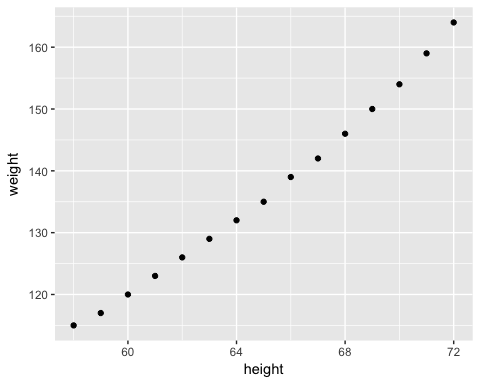 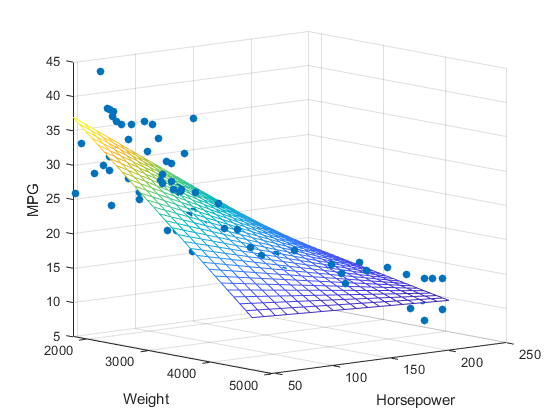

We can also add more than 2 variables (but we can't represent this on a graph as you cannot go beyond 3 dimensions!). But the principle is the same. In practical terms what we say is we are "adjusting" or "controlling" for the other variables. In other words, any effects we observe in our model we can say occur "independently" of the other variables.

One thing to mention before we look at the results. You will see a note at the bottom of the output warning us that "the condition number is large". Don't panic! Here this is mostly because our variables are measured on very different scales (the SIMD ranks go from 1 to 1,600 whereas most datazones have fewer than 5 retailers per 1000 people) so we can ignore it for now. We will look at how to check our models properly in the next practical.

So what do we see in our model? The coefficient for `retailers_adj` has dropped from about 2.8 in the simple model to about 1.2 once we adjust for deprivation (`simd_rank`), but it is still statistically significant. So some of the association we saw in our first model was actually due to deprivation (this is confounding in action!) but there is still an association between tobacco retailers and smoking rates that is independent of the level of deprivation in an area. Remember though that this is still an association. There could be other confounders that we haven't measured!

If you want to see what "adjusting" for deprivation actually does, have a go with the <b>confounding explorer</b> (there's a link to it below). It uses the same urban datazones as our models, and you can switch between the two models and see what happens to the regression line.

https://tc245.github.io/data-science-apps/confounding/

Let's look at research question 3:

3. Is the level of different domains of deprivation in datazones associated with the number of tobacco retailers?

To answer let's put all of the different parts of the SIMD into our model (i.e. the income_rank, health_rank, employment_rank, education_rank, access_rank, crime_rank and housing_rank variables)

In [ ]:
#Look at predicting retailers
multiple_linear_regression = smf.ols('''retailers_adj ~ income_rank +
                                     health_rank +
                                     employment_rank +
                                     education_rank +
                                     access_rank +
                                     crime_rank +
                                     housing_rank''',
                                     data=urban_only).fit()

print(multiple_linear_regression.summary())
print(multiple_linear_regression.conf_int())

Since this is a multiple regression, we can interpret each of the effects as being <b><i>independent</i></b> of all of the other effects in the model.

Looking at the output, only income deprivation (`income_rank`) has a clear association with retailer density. Notice that the coefficient is negative. Remember that rank 1 is the <b>most</b> deprived datazone, so as the rank goes up (i.e. datazones become less deprived) the number of tobacco retailers goes down. The other domains of deprivation are all closely related to each other (and to income deprivation), so once income deprivation is in the model they don't add much extra information.

Be careful with how you interpret this though! It doesn't mean that the other kinds of deprivation don't matter. If you want to see why, have a go with the <b>correlated predictors explorer</b> (there's a link to it below), where you can choose which of the domains go into the model and see what happens to each of the coefficients.

https://tc245.github.io/data-science-apps/predictors/

## Independent analysis exercises<a class="anchor" id="section4"></a>

Take a look at some of the remaining variables. What might be some other research questions you might explore? To get you started, look at the two health variables we haven't looked at yet; `alcohol_admissions` and `drug_admissions`. For the remainder of the class, have a think about any easy research questions you might examine looking at either of these as a dependent variable. And then:

1. Think about how you might need to recode these variables and then have a go at carrying this out
2. Produce relevant descriptive statistics that might start to address your research question
3. Run an appropriate regression model
4. Have a think about what other aditional variables you might need to include, in addition to your independent variable of interest and add these to your model.
5. Have a think about how you might interpret the analysis, perhaps write a few words of interpretation in a markdown cell below the results.

[Back to contents](#contents)

### 5. Some tips on good Coding Practice<a class="anchor" id="section5"></a>

Now is a good point to mention good coding practice. Use a Style Guide (e.g. https://peps.python.org/pep-0008/) to format your code. As they say: Good coding style is like correct punctuation: you can manage without it, butitsuremakesthingseasiertoread. Nice code helps you work faster and helps you avoid mistakes when you're updating your code. Be consistent in:
- Spacing (to make readable)
- Indenting (to show hierarchies in code)
- Line length (under 80 characters)
- Commenting appropriately

Make lots of comments - record all the steps you used when processing the data. When you come back to your code in a couple of weeks or months, you may not remember what you were doing, you need to make sure you have enough comments to remind yourself and pick up where you left off. In a notebook, you can do this by inserting a new Markdown cell, but in a Python script (a `.py` file) you will need to comment using the `#` as we have done in the Code cells above.

"Your closest collaborator is you six months ago and they don’t reply to email" - Paul Wilson


[Back to contents](#contents)

In [ ]:
analysis_data.to_csv("analysis_data.csv", index=False)